# CART Analysis Pipeline

**What you need to do:** fill in the folder where your lifs are saved and check that the channel order matches the one you see in ImageJ (channel 0 is the first channel!). The code has 5 stages:

1. **Discover jobs** — find all .lif files in your folder and identify all the iamges contained within them. Writes `manifest.csv` (including default channel indices `ch_bf`, `ch_bcells`, `ch_vasc`, `ch_cart` per row) so you can check that all the jobs you expect have been identified. To override channels for a specific image acquired differently, open the CSV and edit those columns before running Stage 2 — your edits are preserved if you re-run Stage 1.
2. **Auto-detect masks** — segment chip, tumour, vasculature, B cells and CART cells. A .tif file is written for each image, with the channels:

| Ch | Contents | Editable? |
|---|------------|-----------|
| 0 | BF raw (uint8) | NA |
| 1 | B cells raw (uint8) | NA |
| 2 | Vasculature raw (uint8) | NA |
| 3 | CART cells raw (uint8) | NA |
| 4 | Chip center mask | **Yes** |
| 5 | Tumour mask | **Yes** |
| 6 | Left device mask | No (derived from chip mask) |
| 7 | Right device mask | No (derived from chip mask) |
| 8 | Vasculature mask | No (auto only) |
| 9 | B cells mask | No (auto only) |
| 10 | CART cells mask | No (auto only) |


3. **Curate labels** — this step lets you go through each segmentation and curate the identified tumour or chip region. You can erase or paint in extra region so that the segmentation perfectly matches the tumour/chip.
4. **Analyse** — count cells per region, compute distances from the tumour edge, and compute colocalisation metrics; write `all_counts.csv`, `all_distances.csv`, `all_colocalisation.csv`.
5. **Figures** — save a PNG of each image showing the overlaid segmentation.

In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))
from cart_id import discover_jobs, auto_detect, label_curation, analyse, figures

# ── Pipeline parameters (edit as needed) ─────────────────────────────────────
SOURCE_DIR = Path(r"Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Inputs")  
OUTPUT_DIR = SOURCE_DIR.parent / "Outputs"
# ─────────────────────────────────────────────────────────────────────────────

MANIFEST_PATH = OUTPUT_DIR / "manifest.csv"
CH_BCELLS = 0
CH_VASC = 1 #3 in difficult fileq
CH_BF = 2 #1 in difficult file
# CART cells = last channel

## Stage 1: Discover jobs

In [5]:
discover_jobs.build_and_write_manifest(
    source_dir=SOURCE_DIR,
    output_dir=OUTPUT_DIR,
    manifest_path=MANIFEST_PATH,
    ch_bf=CH_BF,
    ch_bcells=CH_BCELLS,
    ch_vasc=CH_VASC,
    # ch_cart=None  -> defaults to last channel of each image
)

Manifest written: Z:\Bel\Marina_Side_Projects\CART analysis\FINALS\Outputs\manifest.csv
  32/32 images to process


WindowsPath('Z:/Bel/Marina_Side_Projects/CART analysis/FINALS/Outputs/manifest.csv')

## Stage 2: Auto-detect masks

For each processable image, segments the chip device, tumour, vasculature, B cells, and CART cells, then writes an 11-channel `stage2/<name>.tif` with the pixel size embedded in the metadata.

If you have a powerful computer, increase `n_workers`>1 to run multiple jobs simultaneously.

In [6]:
auto_detect.run(MANIFEST_PATH, n_workers=2)

Stage 2: processing 32/32 images (n_workers=2)
  [OK  ] 2026.05.14_FL37_UTD_device1_img0
  [OK  ] 2026.05.14_FL37_ARi_device1_img1
  [OK  ] 2026.05.14_FL37_UTD_device2_img2
  [OK  ] 2026.05.14_FL37_ARi_device2_img3
  [OK  ] 2026.05.14_FL37_UTD_device3_img4
  [OK  ] 2026.05.14_FL37_ARi_device3_img5
  [OK  ] 2026.05.14_FL37_ARi_device4_img6
  [OK  ] 2026.05.14_FL37_UTD_device4_img7
  [OK  ] 2026.05.14_FL41_UTD_device1_img0
  [OK  ] 2026.05.14_FL41_ARi_device1_img1
  [OK  ] 2026.05.14_FL41_UTD_device2_img2
  [OK  ] 2026.05.14_FL41_ARi_device2_img3
  [OK  ] 2026.05.14_FL41_UTD_device3_img4
  [OK  ] 2026.05.14_FL41_ARi_device3_img5
  [OK  ] 2026.05.14_FL41_UTD_device4_img6
  [OK  ] 2026.05.14_FL41_ARi_device4_img7
  [OK  ] CART_day7_FL12_FL12_UTD1_img0
  [OK  ] CART_day7_FL12_FL12_ARi2_img1
  [OK  ] CART_day7_FL12_FL12_UTD2_img2
  [OK  ] CART_day7_FL12_OUT-FL12_ARi3_img3
  [OK  ] CART_day7_FL12_FL12_UTD3_img4
  [OK  ] CART_day7_FL12_FL12_ARi4_img5
  [OK  ] CART_day7_FL12_FL12_UTD4_img6
  [O

## Stage 3: Curate labels *(optional but desirable!)*

Opens an interactive viewer showing the images and their segmentations.

napari viewer. For each image the viewer prefers `stage3/<name>.tif` (a previous curation session) and falls back to `stage2/<name>.tif` (auto). Two label layers are editable:

- **Chip center** (cyan) — the interior channel region
- **Tumour** (red) — the tumour mass

The B-cell, vasculature, and CART raw channels are togglable reference layers (hidden by default — toggle visibility in the layer list). Navigate with **Previous** / **Next**. Edited images are written to `stage3/<name>.tif` immediately on navigation, so progress survives kernel restarts. Click **Done** when finished.

Skip this cell if the auto-detected masks are good enough.

In [2]:
label_curation.main([str(MANIFEST_PATH)])

[INFO] Resumed 32 job(s) from existing stage3/ outputs.
Opening curation viewer for 32 job(s)...


c:\Users\taylorhearn\git_repos\image_quantification\CART_Analysis\cart_id\label_curation.py:220: FutureWarning: Public access to Window.qt_viewer is deprecated and will be removed in
v0.8.0. It is considered an "implementation detail" of the napari
application, not part of the napari viewer model. If your use case
requires access to qt_viewer, please open an issue to discuss.
  (getattr(self.viewer.window, "qt_viewer", None), "destroyed"),


0

Stage 3 complete: 32/32 jobs have stage3 overrides.


## Stage 4 — Analyse

Prefers `stage3/<name>.tif` (curated) and falls back to `stage2/<name>.tif` (auto). For each image:

- **Cell counts** per region (chip, tumour, chip-not-tumour, vasculature, left/right device) for CART cells and B cells.
- **Per-cell distance** from the tumour edge (in µm) with region-membership flags.
- **Colocalisation** between CART and B cells:
  - *Coarse Pearson* — Gaussian blur at 5–50 µm.
  - *Binary proximity fraction* — fraction of one cell type's area within radius r of the other (radii 5–100 µm).
  - *Cumulative cross-type enrichment* (Ripley cross-K style) — the number of one cell type within radius r of the other, divided by the count expected if cells were randomly distributed (1 = random, >1 = recruitment/attraction, <1 = exclusion); border-corrected, radii 5–100 µm.

Writes three CSVs to `OUTPUT_DIR`.


In [2]:
analyse.run(MANIFEST_PATH, output_dir=OUTPUT_DIR, n_workers=4)

Stage 4: analysing 32/32 images (n_workers=4)
Stage 4 done: 32/32 images analysed.
  Z:\Bel\Marina_Side_Projects\CART analysis\FINALS\Outputs\all_counts.csv
  Z:\Bel\Marina_Side_Projects\CART analysis\FINALS\Outputs\all_distances.csv
  Z:\Bel\Marina_Side_Projects\CART analysis\FINALS\Outputs\all_colocalisation.csv


{'counts_csv': WindowsPath('Z:/Bel/Marina_Side_Projects/CART analysis/FINALS/Outputs/all_counts.csv'),
 'distances_csv': WindowsPath('Z:/Bel/Marina_Side_Projects/CART analysis/FINALS/Outputs/all_distances.csv'),
 'coloc_csv': WindowsPath('Z:/Bel/Marina_Side_Projects/CART analysis/FINALS/Outputs/all_colocalisation.csv')}

## Stage 5 — Figures

Generates two sets of outputs:

1. **Per-image QC PNG** — 2-row × 4-column figure (raw channels + mask overlays).
2. **Publication plots** — summary bar charts, distance histograms, and colocalisation line plots loaded from the Stage 4 CSVs.

Uses `stage3/<name>.tif` if present, else `stage2/<name>.tif`.

In [3]:
figures.run(MANIFEST_PATH, figures_dir=OUTPUT_DIR / "figures", n_workers=4)

Stage 5: generating QC figures for 32/32 images (n_workers=4)
  [OK  ] UTD_device1
  [OK  ] ARi_device1
  [OK  ] UTD_device2
  [OK  ] ARi_device2
  [OK  ] UTD_device3
  [OK  ] ARi_device3
  [OK  ] ARi_device4
  [OK  ] UTD_device4
  [OK  ] UTD_device1
  [OK  ] ARi_device1
  [OK  ] UTD_device2
  [OK  ] ARi_device2
  [OK  ] UTD_device3
  [OK  ] ARi_device3
  [OK  ] UTD_device4
  [OK  ] ARi_device4
  [OK  ] FL12_UTD1
  [OK  ] FL12_ARi2
  [OK  ] FL12_UTD2
  [OK  ] OUT-FL12_ARi3
  [OK  ] FL12_UTD3
  [OK  ] FL12_ARi4
  [OK  ] FL12_UTD4
  [OK  ] OUT-FL12_ARi1
  [OK  ] FL32_ARi1_Merged
  [OK  ] FL32_UTD1_Merged
  [OK  ] FL32_ARi2_Merged
  [OK  ] FL32_UTD2_Merged
  [OK  ] FL32_ARi3_Merged
  [OK  ] FL32_UTD3_Merged
  [OK  ] FL32_ARi4_Merged
  [OK  ] FL32_UTD4_Merged
Stage 5 QC figures: 32/32 rendered.


## Stage 6 — Publication plots

Generates the condition-grouped publication figures straight from the Stage 4 CSVs (each plot uses a single CSV as its source of truth):

- **CART counts** (`all_counts.csv`) — scatter by condition, fixed-vs-live bars, normalised tumour/vasculature enrichment.
- **Distances** (`all_distances.csv`) — per-day distance-from-tumour KDEs (in chip, in chip vasculature), split by flow when present.
- **Colocalisation** (`all_colocalisation.csv`) — score-vs-scale line plots per method.

Experimental conditions are inferred from substrings in the image/lif names. Figures are written to `OUTPUT_DIR/plots`.

In [8]:
import pandas as pd
root = r"z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs"
paths = [fr"{root}\all_counts.csv", fr"{root}\all_distances.csv",fr"{root}\all_colocalisation.csv",]

for path in paths:
    df = pd.read_csv(path)
    df["id"] = df["lif_file"] + "_" + df["image"]
    df["patient"] = df["id"].apply(lambda x: 
                                   "FL32" if "fl32" in x.lower()
                                  else "FL33" if "fl33" in x.lower()
                                  else "FL24" if "fl24" in x.lower()
                                  else "FL44" if "fl44" in x.lower()
                                  else "FL7" if "fl7" in x.lower()
                                  else "unknown")
    print(df.patient.unique())  
    df.to_csv(path)

<StringArray>
['FL32', 'FL33', 'FL24', 'FL44', 'FL7']
Length: 5, dtype: str
<StringArray>
['FL32', 'FL33', 'FL24', 'FL44', 'FL7']
Length: 5, dtype: str
<StringArray>
['FL32', 'FL33', 'FL24', 'FL44', 'FL7']
Length: 5, dtype: str


In [9]:
from cart_id import plotting
DROP_PAIRS = [
    ("fl24", "ari3"),
    ("fl32", "ari3"),
    ("fl32", "ari4"),
    ("fl44", "ari1"),
]
plotting.run(OUTPUT_DIR, plots_dir=OUTPUT_DIR / "plots", drop_pairs=DROP_PAIRS)

Stage 6: writing plots to Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\plots
  Dropped 36 row(s) from all_counts.csv matching drop pairs.
  Saved filtered CSV → Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\all_counts_valid_only.csv
  Saved enrichment CSV → Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\plots\enrichment_quantities.csv
  Dropped 144204 row(s) from all_distances.csv matching drop pairs.
  Saved filtered CSV → Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\all_distances_valid_only.csv
  Dropped 528 row(s) from all_colocalisation.csv matching drop pairs.
  Saved filtered CSV → Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\all_colocalisation_valid_only.csv
Stage 6 done: plots written to Z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\plots


(     Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0 patient      day  \
 0               0             0           0    FL32  unknown   
 1               1             1           1    FL32  unknown   
 2               2             2           2    FL32  unknown   
 3               3             3           3    FL32  unknown   
 4               4             4           4    FL32  unknown   
 ..            ...           ...         ...     ...      ...   
 715           715           715         715     FL7  unknown   
 716           716           716         716     FL7  unknown   
 717           717           717         717     FL7  unknown   
 718           718           718         718     FL7  unknown   
 719           719           719         719     FL7  unknown   
 
                          lif_file  pixel_size_um             image  FOV  \
 0    2026.06.25_CART_distribution       1.564603  FL32_ARi1_Merged    1   
 1    2026.06.25_CART_distribution       1.564603  FL32_ARi1_Merge

In [32]:
test = pd.read_csv(r"z:\Marina\Limfoma project\CART\1to1 ratio\CART_distribution\New analysis_CART\Outputs\all_counts_valid_only.csv")
test.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'patient', 'day',
       'lif_file', 'pixel_size_um', 'image', 'FOV', 'cell_type', 'region',
       'cell_count', 'positive_pixels', 'positive_area_um2', 'region_area_px',
       'region_area_um2', 'positive_pixel_pct', 'id'],
      dtype='str')

In [33]:
test["condition"] = test["id"].apply(lambda x: "Ari" if "ari" in x.lower()
                                     else "UTD")

In [40]:
test[(test["region"] == "tumour") & test["cell_type"] == "B cells"]

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,patient,day,lif_file,pixel_size_um,image,FOV,cell_type,region,cell_count,positive_pixels,positive_area_um2,region_area_px,region_area_um2,positive_pixel_pct,id,condition


In [41]:
test[(test["region"] == "tumour") & (test["cell_type"] == "B cells")]

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,patient,day,lif_file,pixel_size_um,image,FOV,cell_type,region,cell_count,positive_pixels,positive_area_um2,region_area_px,region_area_um2,positive_pixel_pct,id,condition
12,12,12,12,FL32,unknown,2026.06.25_CART_distribution,1.564603,FL32_ARi1_Merged,1,B cells,tumour,2541,31319,76668.359867,878836,2.151375e+06,3.563691,2026.06.25_CART_distribution_FL32_ARi1_Merged,Ari
30,30,30,30,FL32,unknown,2026.06.25_CART_distribution,1.564603,FL32_UTD1_Merged,1,B cells,tumour,2031,23891,58484.748863,939068,2.298822e+06,2.544118,2026.06.25_CART_distribution_FL32_UTD1_Merged,UTD
48,48,48,48,FL32,unknown,2026.06.25_CART_distribution,1.564603,FL32_ARi2_Merged,2,B cells,tumour,2759,33276,81459.061426,1093827,2.677669e+06,3.042163,2026.06.25_CART_distribution_FL32_ARi2_Merged,Ari
66,66,66,66,FL32,unknown,2026.06.25_CART_distribution,1.564603,FL32_UTD2_Merged,2,B cells,tumour,2585,35313,86445.591253,859215,2.103343e+06,4.109914,2026.06.25_CART_distribution_FL32_UTD2_Merged,UTD
84,102,102,102,FL32,unknown,2026.06.25_CART_distribution,1.564603,FL32_UTD3_Merged,3,B cells,tumour,2843,37273,91243.646969,851570,2.084628e+06,4.376974,2026.06.25_CART_distribution_FL32_UTD3_Merged,UTD
102,138,138,138,FL32,unknown,2026.06.25_CART_distribution,1.564605,FL32_UTD4_Merged,4,B cells,tumour,882,9074,22213.047090,672161,1.645442e+06,1.349974,2026.06.25_CART_distribution_FL32_UTD4_Merged,UTD
120,156,156,156,FL33,unknown,2026.06.25_CART_distribution,1.564603,FL33_ARi1_Merged,1,B cells,tumour,1813,21057,51547.166582,940570,2.302499e+06,2.238749,2026.06.25_CART_distribution_FL33_ARi1_Merged,Ari
138,174,174,174,FL33,unknown,2026.06.25_CART_distribution,1.564603,FL33_UTD1_Merged,1,B cells,tumour,2150,30541,74763.832197,750424,1.837025e+06,4.069833,2026.06.25_CART_distribution_FL33_UTD1_Merged,UTD
156,192,192,192,FL33,unknown,2026.06.25_CART_distribution,1.564603,FL33_ARi2_Merged,2,B cells,tumour,1626,29107,71253.416063,512990,1.255790e+06,5.673990,2026.06.25_CART_distribution_FL33_ARi2_Merged,Ari
174,210,210,210,FL33,unknown,2026.06.25_CART_distribution,1.564603,FL33_UTD2_Merged,2,B cells,tumour,1486,17712,43358.667856,826564,2.023414e+06,2.142847,2026.06.25_CART_distribution_FL33_UTD2_Merged,UTD


<Axes: xlabel='region_area_um2', ylabel='positive_area_um2'>

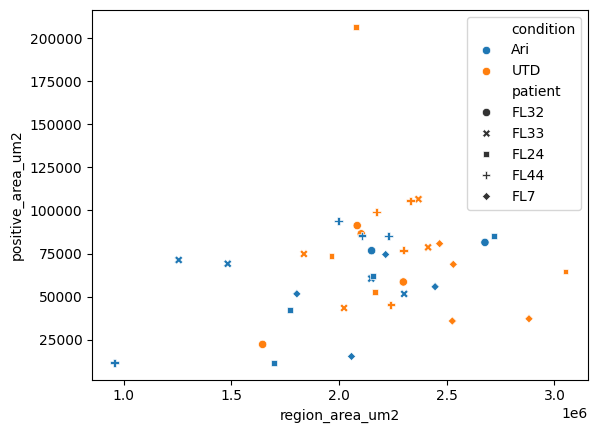

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
fig, ax = plt.subplots()
sns.scatterplot(
    data=test[(test["region"] == "tumour") & (test["cell_type"] == "B cells")],
    x="region_area_um2",
    y="positive_area_um2",
    hue="condition",
    ax=ax,
    style = "patient"
)